# Chargement & Nettoyage
## Arene ML - Prediction de souscription bancaire (Bank Marketing UCI)


Charger le dataset Bank Marketing depuis UCI, explorer, nettoyer et livrer un DataFrame pret pour Mathieu (Arena) et Amos (WebApp).



## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib

pd.set_option('display.max_columns', 30)
print('Imports OK')


Imports OK


## 1. Chargement du dataset (UCI)

On utilise la base officielle UCI Bank Marketing (id=222).  
- **45 211 clients** contactes par une banque portugaise  
- **16 features** (mix numerique + categoriel)  
- **1 cible** : `y` -- `yes` / `no` (souscription au depot a terme)


In [2]:
bank_marketing = fetch_ucirepo(id=222)

X = bank_marketing.data.features
y = bank_marketing.data.targets

print('Metadata :')
print(bank_marketing.metadata)
print('\nVariable information :')
print(bank_marketing.variables)


Metadata :
{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to pr

In [3]:
print(f'Forme de X : {X.shape}')
print(f'Forme de y : {y.shape}')
print('\nPremiere ligne :')
X.head()


Forme de X : (45211, 16)
Forme de y : (45211, 1)

Premiere ligne :


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN


## 2. Exploration initiale (EDA)

In [4]:
df = X.copy()
df['y'] = y['y']

print('=== Types techniques (pandas) ===')
print(df.dtypes)
print(f'\nForme : {df.shape}')


=== Types techniques (pandas) ===
age             int64
job            object
marital        object
education      object
default        object
balance         int64
housing        object
loan           object
contact        object
day_of_week     int64
month          object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
y              object
dtype: object

Forme : (45211, 17)


In [5]:
print('=== Statistiques descriptives ===')
df.describe(include='all').T


=== Statistiques descriptives ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,44923,11,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,43354,3,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,32191,2,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


=== Distribution de la cible ===
     count  pct (%)
y                  
no   39922     88.3
yes   5289     11.7


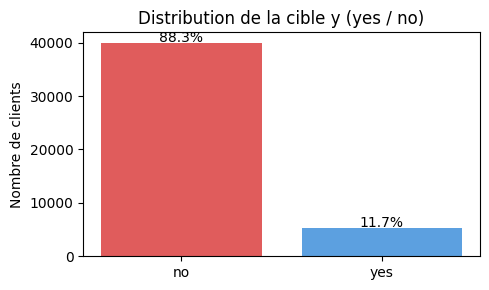

ATTENTION : 88% no / 12% yes -- metrique retenue : ROC-AUC + recall(yes)


In [6]:
# Distribution de la cible -- desequilibre de classes
counts = df['y'].value_counts()
pct = df['y'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'count': counts, 'pct (%)': pct.round(1)})
print('=== Distribution de la cible ===')
print(summary)

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(summary.index, summary['count'], color=['#e05c5c', '#5ca0e0'])
ax.set_title('Distribution de la cible y (yes / no)')
ax.set_ylabel('Nombre de clients')
for bar, (_, row) in zip(ax.patches, summary.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 200,
            f'{row["pct (%)"]:.1f}%',
            ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=120)
plt.show()
print('ATTENTION : 88% no / 12% yes -- metrique retenue : ROC-AUC + recall(yes)')


## 3. Valeurs manquantes



**Particularite UCI Bank Marketing :** la valeur `unknown` apparait dans `job`, `education`, `contact`, `poutcome`. Selon UCI, c'est une **categorie officielle** (pas un NaN). On la detecte explicitement.


In [7]:
# NaN classiques
manquants = df.isna().sum()
pourcentage = (df.isna().mean() * 100).round(1)
resume = pd.DataFrame({'manquants': manquants, 'pct (%)': pourcentage})
print('=== NaN classiques ===')
nan_df = resume[resume['manquants'] > 0]
if nan_df.empty:
    print('Aucun NaN detecte -- le dataset UCI est propre sur ce point.')
else:
    print(nan_df.sort_values('pct (%)', ascending=False))


=== NaN classiques ===
           manquants  pct (%)
poutcome       36959     81.7
contact        13020     28.8
education       1857      4.1
job              288      0.6


In [8]:
# Valeurs 'unknown' par colonne
cols_with_unknown = [
    c for c in df.columns
    if df[c].dtype == object and (df[c].str.lower() == 'unknown').any()
]
print('=== Colonnes contenant unknown ===')
for col in cols_with_unknown:
    n = (df[col].str.lower() == 'unknown').sum()
    pct = n / len(df) * 100
    print(f'  {col:15s} -> {n:5d} unknowns ({pct:.1f}%)')

print()
print('Decision retenue : unknown = categorie officielle UCI, conserve tel quel.')
print('Option alternative : remplacer par le mode -- a comparer via cross-val si besoin.')


=== Colonnes contenant unknown ===

Decision retenue : unknown = categorie officielle UCI, conserve tel quel.
Option alternative : remplacer par le mode -- a comparer via cross-val si besoin.


## 4. Valeurs aberrantes (outliers)


On inspecte les colonnes numeriques les plus exposees.


Colonnes numeriques : ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']


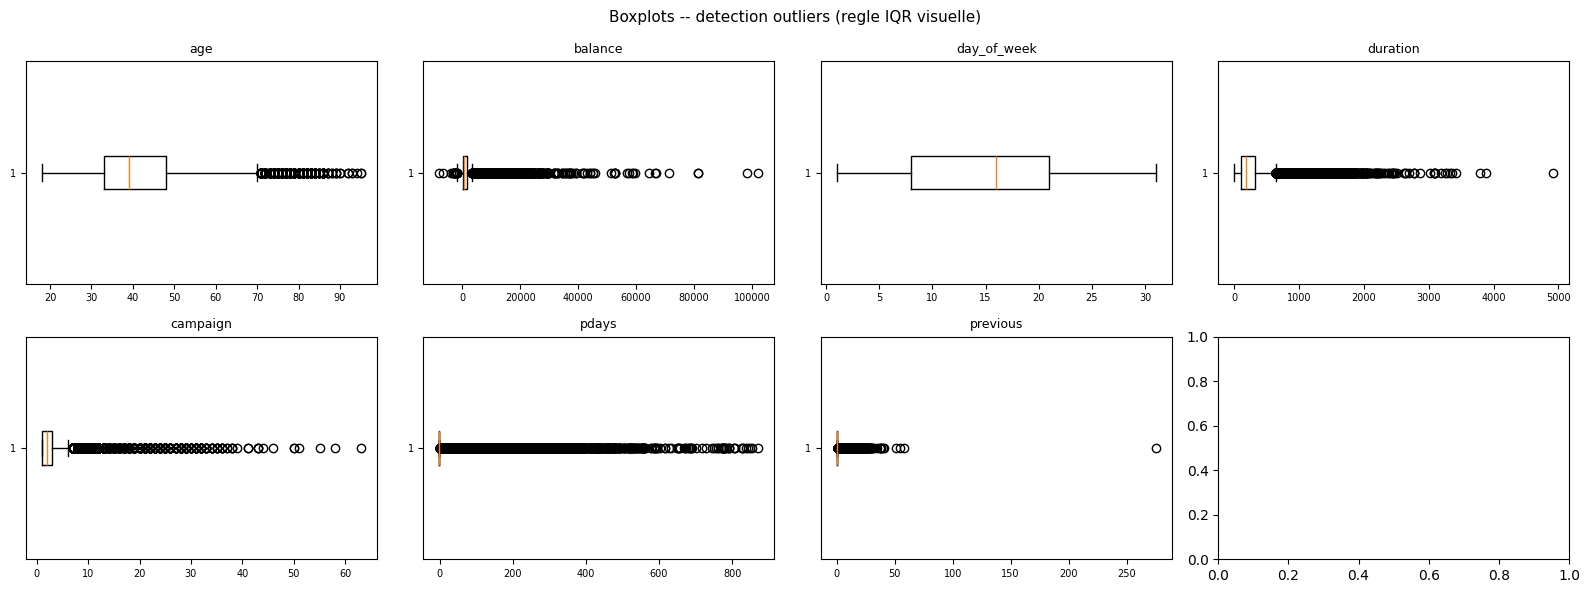

In [9]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('Colonnes numeriques :', num_cols)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()
for i, col in enumerate(num_cols[:8]):
    axes[i].boxplot(df[col].dropna(), vert=False)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)
plt.suptitle('Boxplots -- detection outliers (regle IQR visuelle)', fontsize=11)
plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=120)
plt.show()


In [10]:
# Quantification IQR sur les variables les plus exposees
for col in ['balance', 'duration', 'campaign']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    basse = Q1 - 1.5 * IQR
    haute = Q3 + 1.5 * IQR
    n_out = ((df[col] < basse) | (df[col] > haute)).sum()
    print(f'{col:12s} -> bornes [{basse:.0f}, {haute:.0f}] | outliers : {n_out} ({n_out/len(df)*100:.1f}%)')

print()
print('Decision : outliers conserves -- valeurs reelles (comptes negatifs, campagnes intenses).')
print('duration : conservee pour comparatif mais inutilisable en production.')


balance      -> bornes [-1962, 3462] | outliers : 4729 (10.5%)
duration     -> bornes [-221, 643] | outliers : 3235 (7.2%)
campaign     -> bornes [-2, 6] | outliers : 3064 (6.8%)

Decision : outliers conserves -- valeurs reelles (comptes negatifs, campagnes intenses).
duration : conservee pour comparatif mais inutilisable en production.


## 5. Le cas `duration` -- fuite de donnees en production

> La duree du dernier appel est ultra-predictive mais on ne la connait pas avant d'appeler.  
> On cree deux versions du dataset pour que Mathieu puisse comparer l'impact.


In [11]:
df_corr = df.copy()
df_corr['y_bin'] = (df_corr['y'] == 'yes').astype(int)
corr_val = df_corr['duration'].corr(df_corr['y_bin'])
print(f'Correlation Pearson duration / y_bin : {corr_val:.3f}')
print()
print('-> 2 versions de X seront exportees :')
print('   X_full   : toutes les features (avec duration)')
print('   X_no_dur : sans duration (version production realiste)')


Correlation Pearson duration / y_bin : 0.395

-> 2 versions de X seront exportees :
   X_full   : toutes les features (avec duration)
   X_no_dur : sans duration (version production realiste)


In [12]:
import os
os.makedirs('../data', exist_ok=True)

# Version complète (avec duration — pour comparatif dans l'Arène)
df.to_csv('../data/bank_processed.csv', index=False)

# Version production (sans duration — inutilisable en prod car inconnue avant l'appel)
df.drop(columns=['duration']).to_csv('../data/bank_processed_no_duration.csv', index=False)

print('Exports OK :')
print(f'  ../data/bank_processed.csv              -> {len(df)} lignes, {df.shape[1]} colonnes')
print(f'  ../data/bank_processed_no_duration.csv  -> {len(df)} lignes, {df.shape[1]-1} colonnes')

Exports OK :
  ../data/bank_processed.csv              -> 45211 lignes, 17 colonnes
  ../data/bank_processed_no_duration.csv  -> 45211 lignes, 16 colonnes
